## LET'S TALK ABOUT TYPE VALIDATION

- Used: from typing import List, Dict, Optional


In [ ]:
from pydantic import BaseModel
from typing import List, Dict, Optional

# step 1: model
class Patient(BaseModel):
    name: str
    age: int
    weight: float
    married: bool
    allergies: List[str] # import List from typing 
    # WHY??: ALLERGIES IS LIST AND DATA INSIDE ALLERGIES IS STR --> 2 LEVEL DATA VALIDATION 
    contact_detials: Dict[str, str]

# In model every field is required but we can make it optional 
    address : Optional[str] = None # none is for defult value
    

def insert_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")

def updated_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")


#step 2: pass raw input data (created dict)

patient_info = {'name': 'aryan', 'age':30, 'weight': 75.2, 'married': True, 'allergies': ['pollen', 'dust'], 'contact_detials': {'email' : 'abc@gmail.com', 'Phone' : '1264321416'} } # if you will right str instead of int in age it will raise error
patient1 = Patient(**patient_info) #unpack dict


#step 3:
insert_patient_data(patient1)

aryan
30
75.2
True
['pollen', 'dust']
{'email': 'abc@gmail.com', 'Phone': '1264321416'}
None
Inserted into database


## LET'S TALK ABOUT DATA VALIDATION

- For the upcoming data is correct or not.
- Used: EmailStr, AnyUrl

In [ ]:
from pydantic import BaseModel, EmailStr, AnyUrl
from typing import List,Dict, Optional

# step 1: model
class Patient(BaseModel):
    name: str
    age: int
    email: EmailStr # For data validation if you miss to write @ it will raise error
    linkedin_url: AnyUrl # data validation if you miss to write http it will raise error 
    weight: float
    married: bool
    allergies: List[str] 
    contact_detials: Dict[str, str] 
    address : Optional[str] = None 
    

def insert_patient_data(patient: Patient):
    print(patient.name)
    print(patient.email)
    print(patient.linkedin_url)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")

def updated_patient_data(patient: Patient):
    print(patient.name)
    print(patient.email)
    print(patient.linkedin_url)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")


#step 2: pass raw input data (created dict)

patient_info = {'name': 'aryan', 'email': 'aryan@gmail.com', 'linkedin_url':'http://linkedin.com/116','age':30, 'weight': 75.2, 'married': True, 'allergies': ['pollen', 'dust'], 'contact_detials': {'Phone' : '1264321416'} } # if you will right str instead of int in age it will raise error
patient1 = Patient(**patient_info) #unpack dict


#step 3:
insert_patient_data(patient1)

aryan
aryan@gmail.com
http://linkedin.com/116
30
75.2
True
['pollen', 'dust']
{'Phone': '1264321416'}
None
Inserted into database


## CUSTOM DATA VALIDATION

- Age is greater then less then etc..
- You can use on both data type numeric and str
- Used: Field
- Field function is not only for data validation also used for metadata, default values


![ChatGPT Image May 21, 2026, 02_45_11 PM.png](<attachment:ChatGPT Image May 21, 2026, 02_45_11 PM.png>)
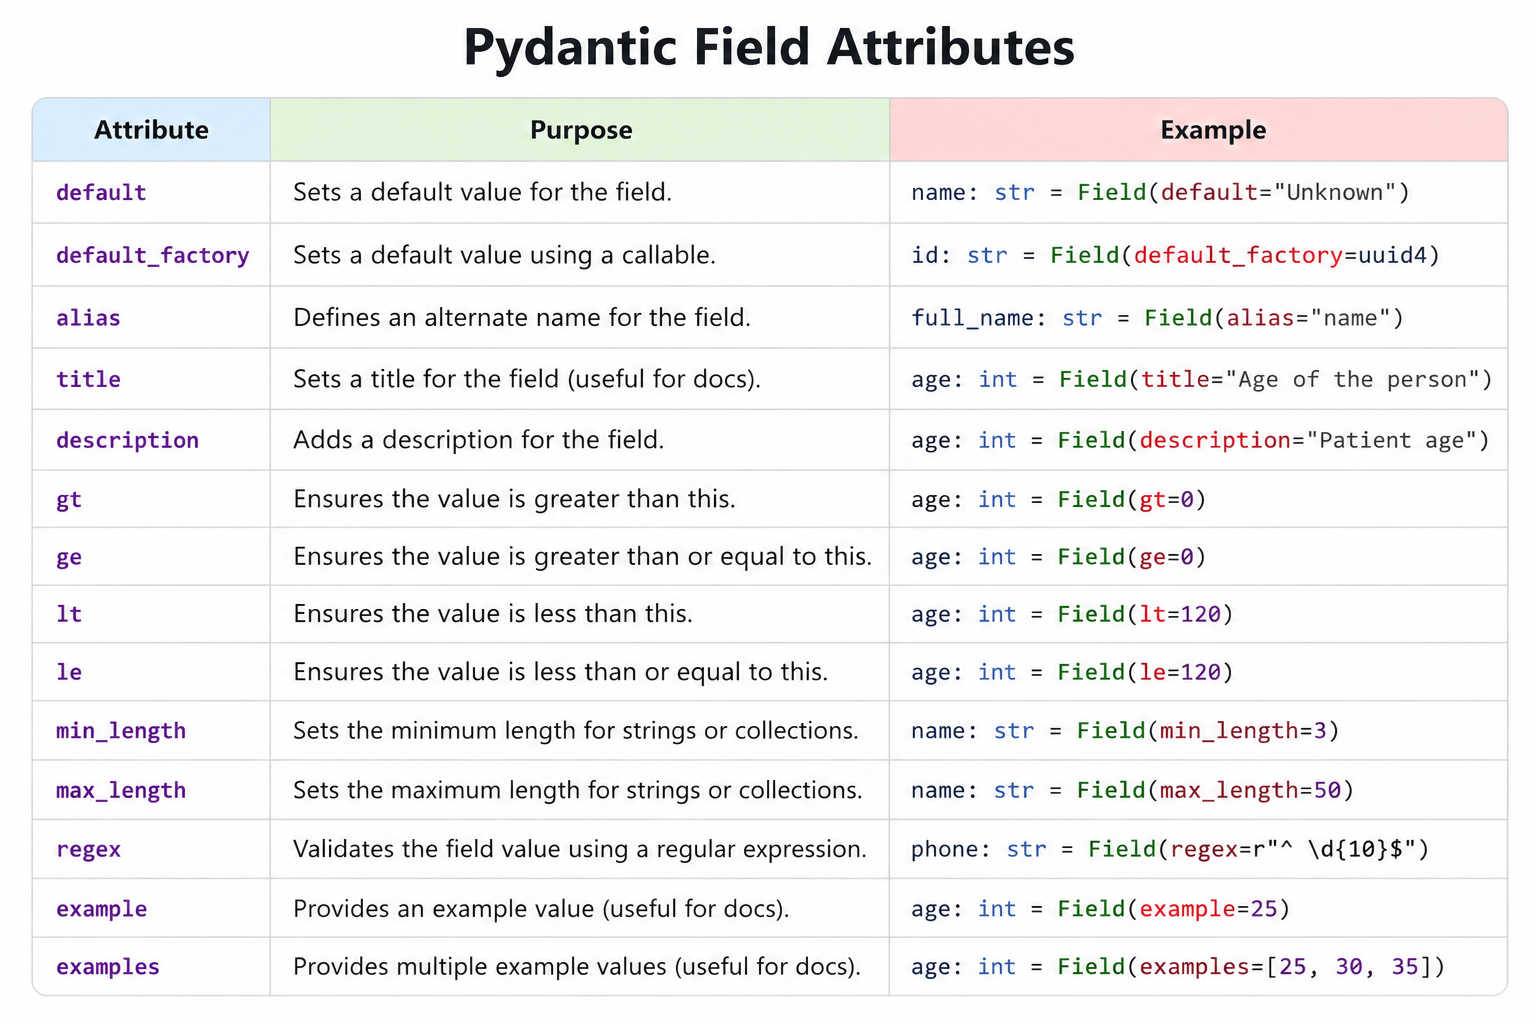

In [ ]:
from pydantic import BaseModel, EmailStr, AnyUrl, Field
from typing import List,Dict, Optional, Annotated

# step 1: model
class Patient(BaseModel):

    # Custom MetaData
    name: Annotated[str, Field(max_length=50, title='Name of the patient', description='Give the name of the patient in less than 50 chars', examples=['Aryan', 'Bunny'])]

    age: int

    weight: float = Field(gt=0) # custom data validation (gt --> grater than equal)
    # If range needed:
    # weight: float = Field(gt=0, lt=120)

    married: Annotated[bool, Field(default=None, description='Is the patient married or not')]

    allergies: Annotated[List[str], Field(default= None, max_length=5)]
    contact_detials: Dict[str, str] 
    address : Optional[str] = None 
    

def insert_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")

def updated_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.allergies)
    print(patient.contact_detials)
    print(patient.address)
    print("Inserted into database")


#step 2: pass raw input data (created dict)

patient_info = {'name': 'aryan','age': 30, 'weight': '75.2', 'married': True, 'contact_detials': {'Phone' : '1264321416'} } # if you will right str instead of int in age it will raise error
patient1 = Patient(**patient_info) #unpack dict


#step 3:
insert_patient_data(patient1)

aryan
30
75.2
True
None
{'Phone': '1264321416'}
None
Inserted into database


- Weight value is passed as string,
- but Pydantic automatically converts it to float
- if conversion is possible.

Example:
weight = "75.2"

Pydantic converts:
"75.2"  →  75.2

### Automatic conversion can:

- hide bugs
- allow dirty data
- create unexpected behavior

- smartness can be dangerous


In [37]:
# you can use:

#--> StrictFloat
#--> StrictInt
#--> StrictStr
#--> StrictBool

class Patient(BaseModel):
    weight: float = Field(gt=0, strict=True)


def insert_patient_data(patient: Patient):
    print(patient.weight)


patient_info = {'weight': '74.5'}
patient1 = Patient(**patient_info)

insert_patient_data(patient1)



ValidationError: 1 validation error for Patient
weight
  Input should be a valid number [type=float_type, input_value='74.5', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type